In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# EDA

In [2]:
df = pd.read_csv("concrete_data.csv")
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print("İnformations: ")
df.info()
print("İsnull Values: \n", df.isnull().sum())
display(df.head(5))
print("Describing: ")
display(df.describe())

Shape:  (1030, 9)
Columns:  Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')
İnformations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB
İsnull Values: 
 Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water 

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


Describing: 


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


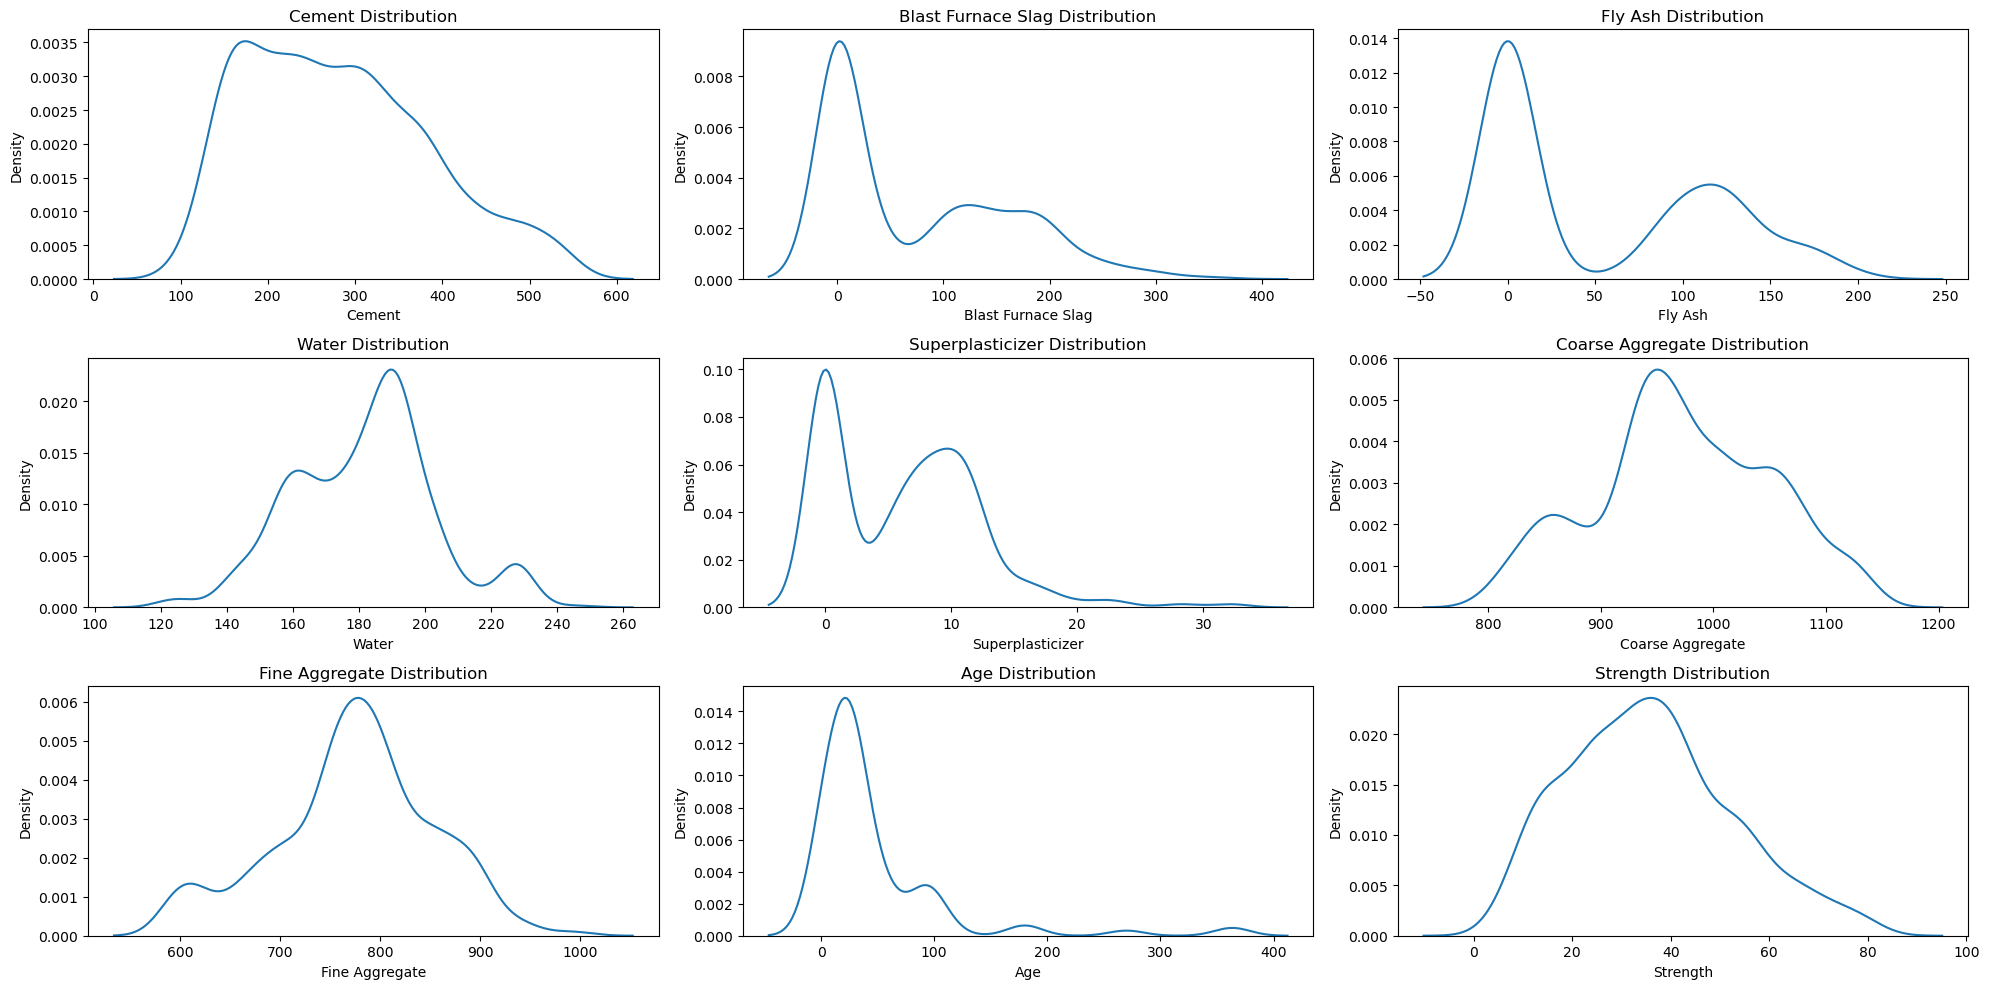

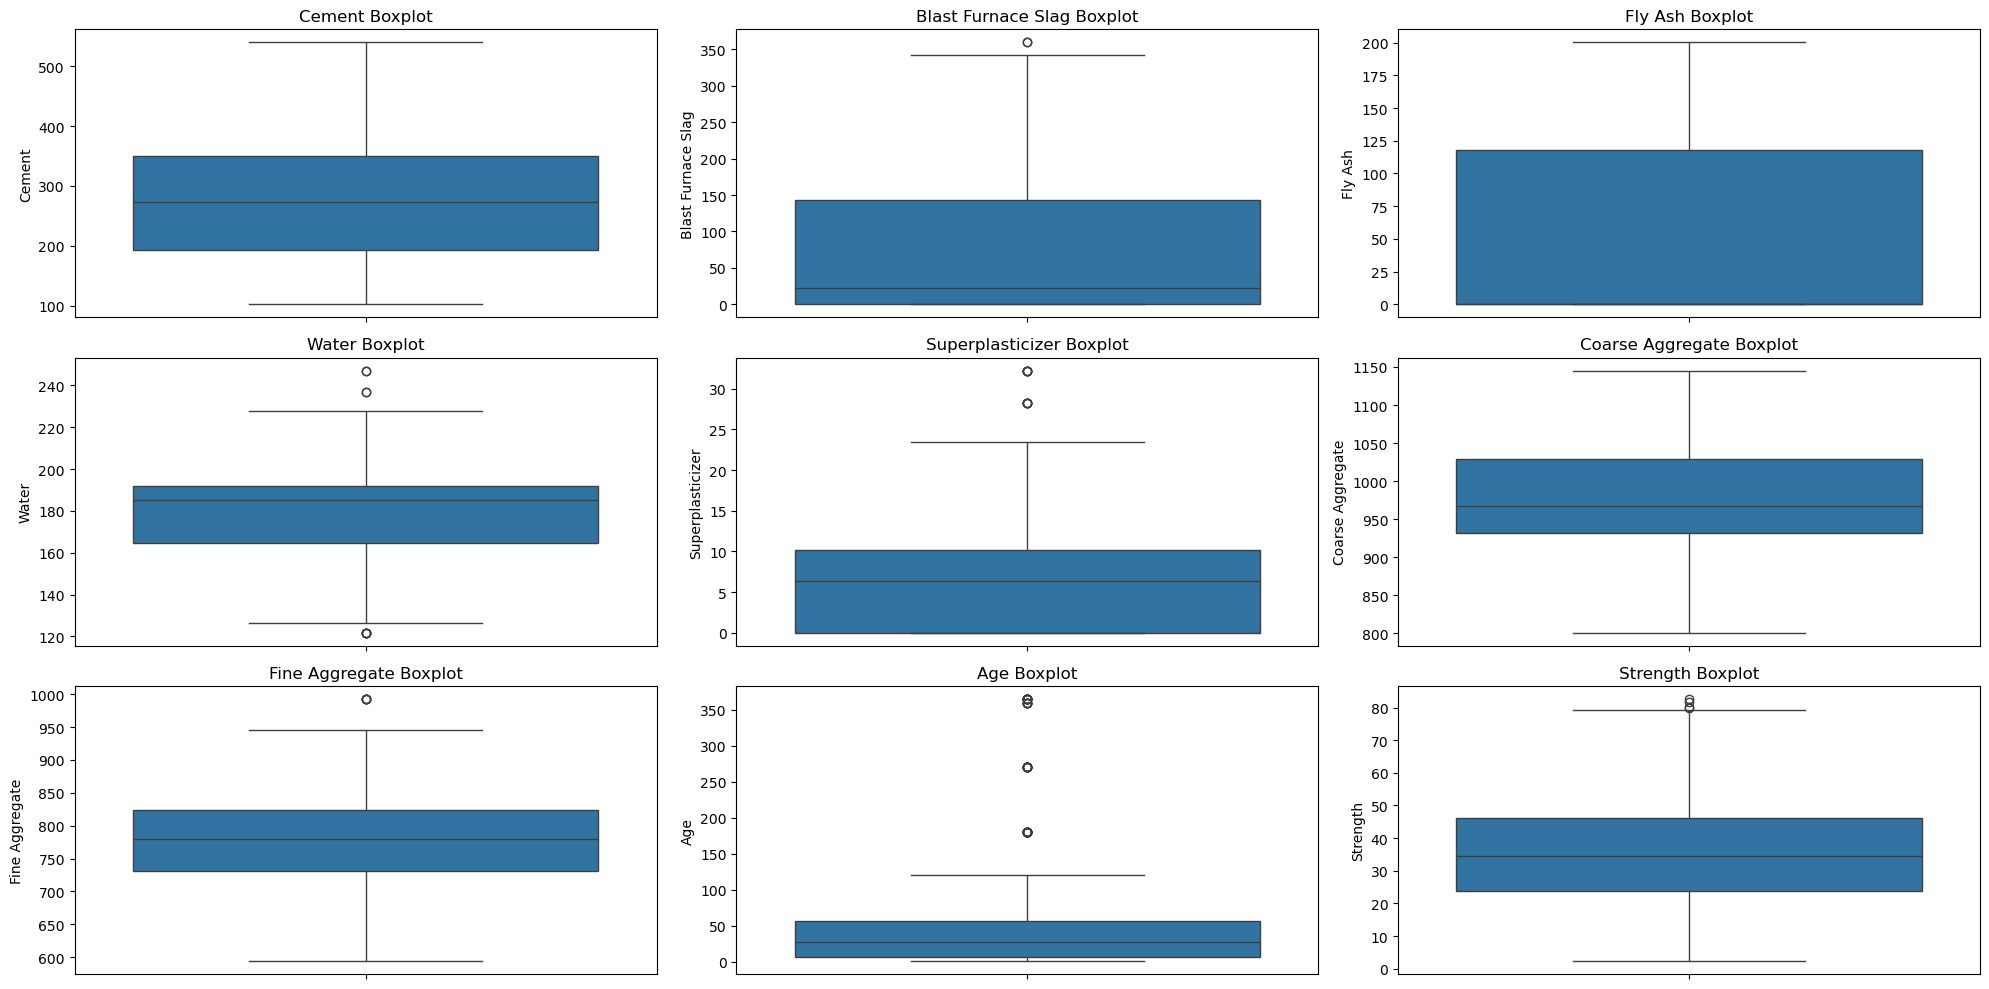

In [3]:
def see_numerical(data):
    numerical = data.select_dtypes("number").columns
    numerical = list(numerical)

    fig, ax = plt.subplots(3,3,figsize=(20,10))
    ax = ax.flatten()

    for i, col in enumerate(numerical):
        sns.kdeplot(
            x = col,
            data = data,
            ax = ax[i]
        )
        ax[i].set_title(f"{col} Distribution")
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(3,3,figsize=(20,10))
    ax2 = ax2.flatten()

    for k, col in enumerate(numerical):
        sns.boxplot(
            data = data,
            y = col,
            ax = ax2[k]
        )
        ax2[k].set_title(f"{col} Boxplot")
    plt.tight_layout()
    plt.show()

see_numerical(df)

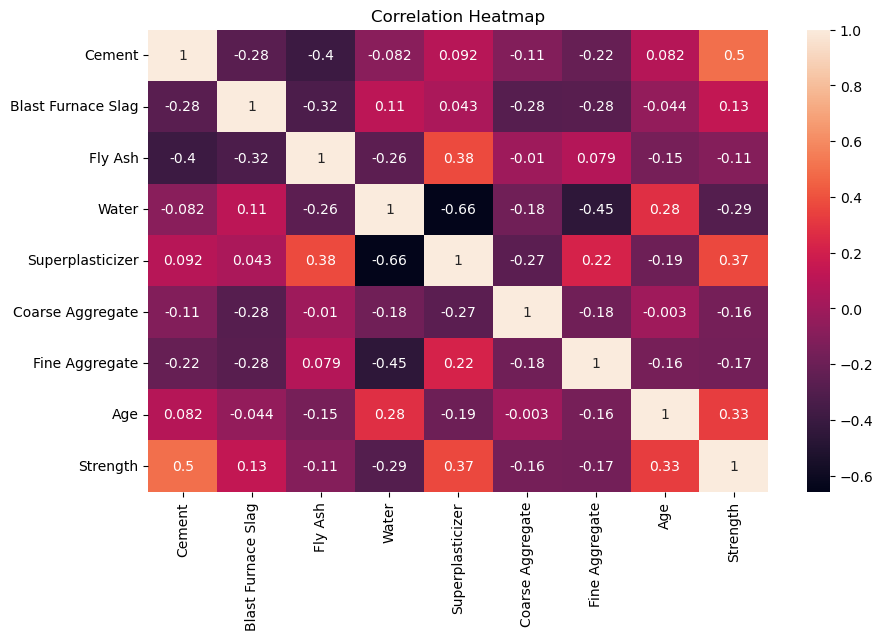

In [4]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

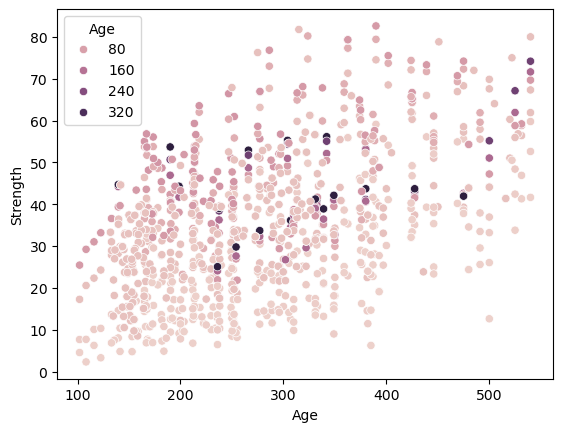

In [5]:
sns.scatterplot(x="Cement", y="Strength", hue="Age", data=df)
plt.xlabel("Age")
plt.ylabel("Strength")
plt.show()

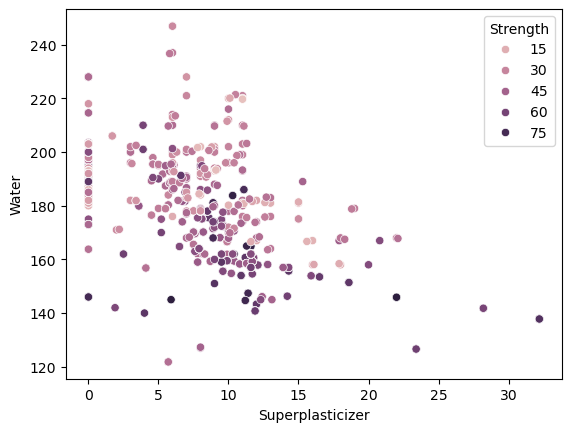

In [6]:
sns.scatterplot(x="Superplasticizer", y="Water", hue="Strength", data=df)
plt.xlabel("Superplasticizer")
plt.ylabel("Water")
plt.show()

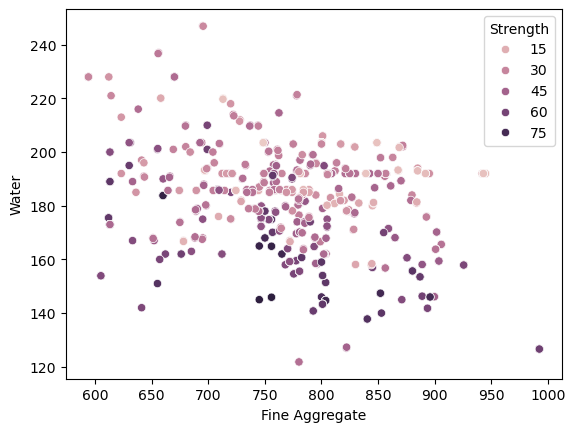

In [7]:
sns.scatterplot(x="Fine Aggregate", y="Water", hue="Strength", data=df)
plt.xlabel("Fine Aggregate")
plt.ylabel("Water")
plt.show()

# Model Building

In [8]:
from sklearn.model_selection import train_test_split
X = df.drop("Strength", axis=1)
y = df["Strength"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_and_evaluate(models, X_train, X_test, y_train, y_test):

    def calculate_metrics(true, prediction):
        mse = mean_squared_error(true, prediction)
        mae = mean_absolute_error(true, prediction)
        r2 = r2_score(true, prediction)
        return (mse, mae, r2)
    
    results = []
    for name, model in models.items() :
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        train_mse, train_mae, train_r2 = calculate_metrics(y_train, y_train_pred)
        test_mse, test_mae, test_r2 = calculate_metrics(y_test, y_test_pred)
        overfit_gap = train_r2 - test_r2
        result = {
            "model_name": name,
            "train_mse": train_mse,
            "train_mae": train_mae,
            "train_r2": train_r2,
            "test_mse": test_mse,
            "test_mae": test_mae,
            "test_r2": test_r2,
            "overfit_gap": overfit_gap
        }
        results.append(result)

    results = pd.DataFrame(results)
    results = results.sort_values("test_r2", ascending=False)
    return results

models = {
    "decision_tree_regressor": DecisionTreeRegressor(random_state=42),
    "random_forest_regressor": RandomForestRegressor(random_state=42),
    "adaboost_regressor": AdaBoostRegressor(random_state=42),
    "gradient_boosting_regressor": GradientBoostingRegressor(random_state=42)
}
result1 = train_and_evaluate(models, X_train, X_test, y_train, y_test)

In [10]:
result1

,model_name,train_mse,train_mae,train_r2,test_mse,test_mae,test_r2,overfit_gap
1,random_forest_regressor,4.912912,1.417526,0.982769,18.629727,3.009334,0.928315,0.054454
3,gradient_boosting_regressor,15.296109,2.954994,0.946354,19.561277,3.374933,0.924731,0.021623
0,decision_tree_regressor,1.383628,0.123882,0.995147,38.426307,3.994496,0.852140,0.143007
2,adaboost_regressor,52.791298,6.168581,0.814850,51.373084,5.935924,0.802323,0.012528


In [11]:
from sklearn.model_selection import GridSearchCV

def tuning():
    rf_params = {
        "n_estimators": [100,150,200,300],
        "max_depth": [3,4,5,10,None],
        "min_samples_split": [2,3,5,10]
    }
    dtr_params = {
        "max_depth": [3,4,5,10,None],
        "min_samples_split": [2,3,5,10],
        "min_samples_leaf": [2,3,5,10]
    }
    ab_params = {
        "n_estimators": [50,100,150,200],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
    }
    gdb_params = {
        "n_estimators": [50,100,150,200],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [3,4,5,7]
    }
    models = [
        ("RFR", RandomForestRegressor(), rf_params),
        ("DTR", DecisionTreeRegressor(), dtr_params),
        ("ADR", AdaBoostRegressor(), ab_params),
        ("GBR", GradientBoostingRegressor(), gdb_params)
    ]
    params = []
    for name, model, param in models:
        grid = GridSearchCV(estimator=model, param_grid=param, scoring="r2", n_jobs=-1, cv=5)
        grid.fit(X_train, y_train)
        result = (name, grid.best_params_)
        params.append(result)
    return params

params = tuning()

In [12]:
params

[('RFR', {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}),
 ('DTR', {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}),
 ('ADR', {'learning_rate': 0.2, 'n_estimators': 200}),
 ('GBR', {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200})]

In [13]:
tuning_models = {
    "decision_tree_regressor": DecisionTreeRegressor(random_state=42, **params[1][1]),
    "random_forest_regressor": RandomForestRegressor(random_state=42, **params[0][1]),
    "adaboost_regressor": AdaBoostRegressor(random_state=42, estimator=DecisionTreeRegressor(max_depth=3), **params[2][1]),
    "gradient_boosting_regressor": GradientBoostingRegressor(random_state=42, **params[3][1])
}
tuning_result = train_and_evaluate(tuning_models, X_train, X_test, y_train, y_test)

In [14]:
tuning_result

,model_name,train_mse,train_mae,train_r2,test_mse,test_mae,test_r2,overfit_gap
3,gradient_boosting_regressor,2.388338,0.816372,0.991624,12.822872,2.430632,0.950659,0.040964
1,random_forest_regressor,4.824380,1.425723,0.983080,18.714040,3.022760,0.927991,0.055089
0,decision_tree_regressor,9.249695,2.090787,0.967559,47.264748,4.661556,0.818131,0.149428
2,adaboost_regressor,56.223886,6.346625,0.802812,50.682378,5.891489,0.804980,-0.002169


In [15]:
result1

,model_name,train_mse,train_mae,train_r2,test_mse,test_mae,test_r2,overfit_gap
1,random_forest_regressor,4.912912,1.417526,0.982769,18.629727,3.009334,0.928315,0.054454
3,gradient_boosting_regressor,15.296109,2.954994,0.946354,19.561277,3.374933,0.924731,0.021623
0,decision_tree_regressor,1.383628,0.123882,0.995147,38.426307,3.994496,0.852140,0.143007
2,adaboost_regressor,52.791298,6.168581,0.814850,51.373084,5.935924,0.802323,0.012528
